DataSet Link: https://www.kaggle.com/datasets/bhanupratapbiswas/olympic-data

### 1. Importing Libraries

In [2]:
# Importing required libraries for data analysis and visualization

import pandas as pd               # used for loading and analyzing dataset
import numpy as np                # used for numerical operations
import matplotlib.pyplot as plt   # used for basic data visualization
import seaborn as sns             # used for advanced statistical visualization

### 2. Loading Data

In [3]:
# Loading the Olympic dataset into a DataFrame
df = pd.read_csv("/content/dataset_olympics.csv")
df.columns = df.columns.str.lower()

In [5]:
# Displaying the dataset
df.head()

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


**observations:**
- The dataset contains 70,000 rows and 15 columns.
- Each row represents an athlete’s participation in an Olympic event.

### 3. Checking basic info

In [6]:
# Check dataset shape (number of rows and columns)
df.shape

(70000, 15)

In [7]:
# Check column names
df.columns

Index(['id', 'name', 'sex', 'age', 'height', 'weight', 'team', 'noc', 'games',
       'year', 'season', 'city', 'sport', 'event', 'medal'],
      dtype='object')

In [8]:
# Check dataset structure, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      70000 non-null  int64  
 1   name    70000 non-null  object 
 2   sex     70000 non-null  object 
 3   age     67268 non-null  float64
 4   height  53746 non-null  float64
 5   weight  52899 non-null  float64
 6   team    70000 non-null  object 
 7   noc     70000 non-null  object 
 8   games   70000 non-null  object 
 9   year    70000 non-null  int64  
 10  season  70000 non-null  object 
 11  city    70000 non-null  object 
 12  sport   70000 non-null  object 
 13  event   70000 non-null  object 
 14  medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


**observations:**
- The dataset contains both numerical (int64, float64) and categorical (object) data types
- The dataset uses approximately 8.0+ MB of memory.
- Some columns such as Age, Height, Weight, and Medal contain missing values.

### 4. Handling missing values

In [9]:
# checking for NULL values
df.isnull().sum()

,0
id,0
name,0
sex,0
age,2732
height,16254
weight,17101
team,0
noc,0
games,0
year,0


In [11]:
# Fill missing values

df["age"] = df["age"].fillna(df["age"].median())          # use median for Age
df['height'] = df['height'].fillna(df['height'].mean())   # use mean for Height
df['weight'] = df['weight'].fillna(df['weight'].mean())   # use mean for Weight
df['medal'] = df['medal'].fillna("no medal")              # replace missing medals with "No Medal"

In [12]:
# Check again for missing values
df.isnull().sum()

,0
id,0
name,0
sex,0
age,0
height,0
weight,0
team,0
noc,0
games,0
year,0


**observations:**
- Age missing values were replaced using the median value.
- Height and Weight missing values were replaced using the mean value.
- Missing values in Medal were replaced with "No Medal".

### 5. Handling Duplicate Values

In [13]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(383)

In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

In [15]:
# Check duplicates again
df.duplicated().sum()

np.int64(0)

### 6. Data Understanding

In [16]:
# Summary statistics of numerical columns
df.describe()

,id,age,height,weight,year
count,69617.000000,69617.000000,69617.000000,69617.000000,69617.000000
mean,18073.006378,25.523378,175.504865,70.900216,1978.021862
std,10240.599374,6.133014,9.123870,12.393330,29.982224
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9303.000000,22.000000,170.000000,64.000000,1960.000000
50%,18029.000000,25.000000,175.505303,70.900216,1984.000000
75%,26965.000000,28.000000,180.000000,75.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [17]:
# Check if the target variable (Medal) is imbalanced
print("Medal value counts:")
print(df['medal'].value_counts())
print()
print("Medal percentage distribution:")
print(df['medal'].value_counts(normalize=True) * 100)

Medal value counts:
medal
no medal    59931
Gold         3290
Bronze       3208
Silver       3188
Name: count, dtype: int64

Medal percentage distribution:
medal
no medal    86.086732
Gold         4.725857
Bronze       4.608070
Silver       4.579341
Name: proportion, dtype: float64


**observations:**
- The dataset is highly imbalanced.
- 'No Medal' accounts for ~86% of records.
- Gold, Silver, and Bronze each represent only ~4-5%.
- This imbalance should be considered in any further modeling.

In [18]:
# Count unique values in each column
df.nunique()

,0
id,35658
name,35556
sex,2
age,68
height,88
weight,174
team,827
noc,226
games,51
year,35


**observations:**
- The average athlete age is around 25 years.
- Height and weight show wide variation across athletes.
- The dataset contains both numerical and categorical features.
- The data includes athletes from multiple Olympic years and sports.

In [19]:
# Check data types of each column
df.dtypes

,0
id,int64
name,object
sex,object
age,float64
height,float64
weight,float64
team,object
noc,object
games,object
year,int64


**observations:**
- The columns ID, Age, Height, Weight, and Year are stored as integer or float numerical types,
- The Name column is stored as an object type (likely a string).

### 7. Outlier Detection and Treatment

In [20]:
# Select numerical columns for outlier analysis
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [21]:
# Detect and count outliers using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, ":", outliers, "outliers")

id : 0 outliers
age : 3139 outliers
height : 2514 outliers
weight : 5237 outliers
year : 65 outliers


In [22]:
# Remove outliers using IQR range
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

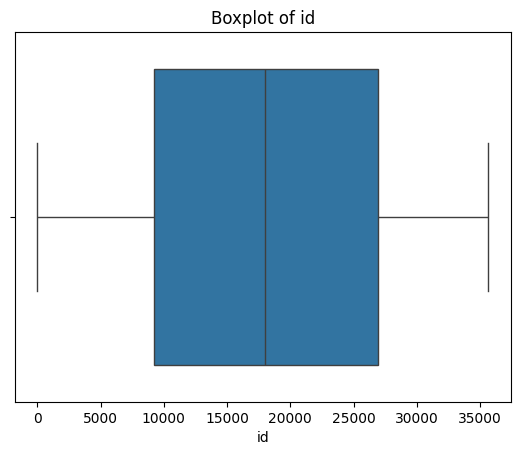

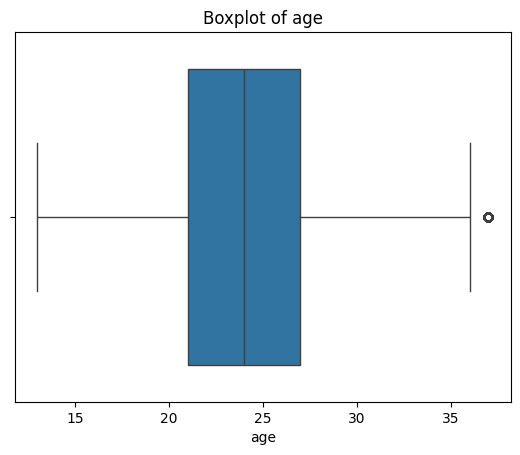

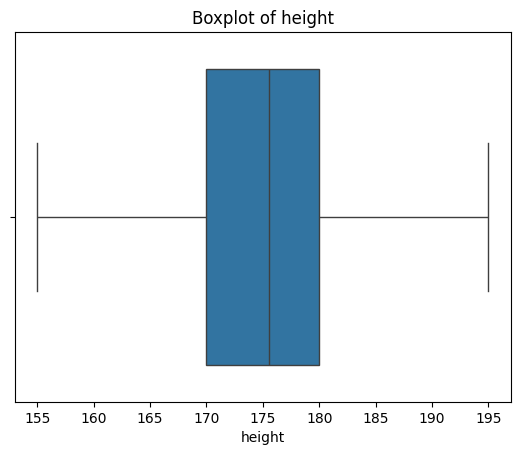

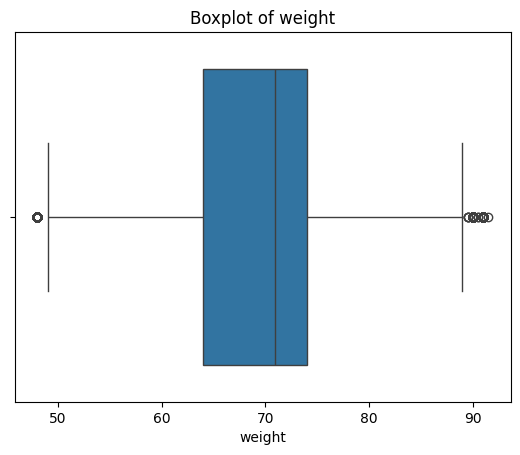

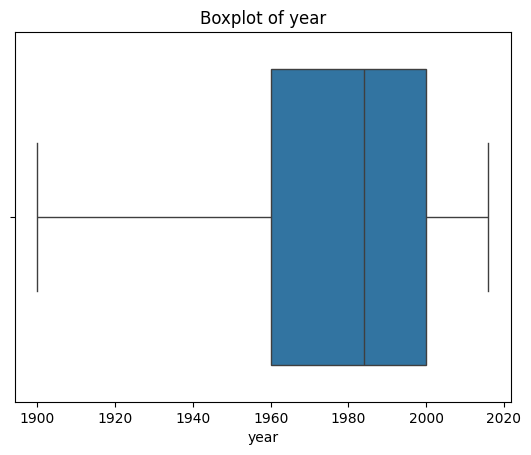

In [23]:
# Recheck using boxplots
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title("Boxplot of " + col)
    plt.show()

### 8. Univariate Analysis

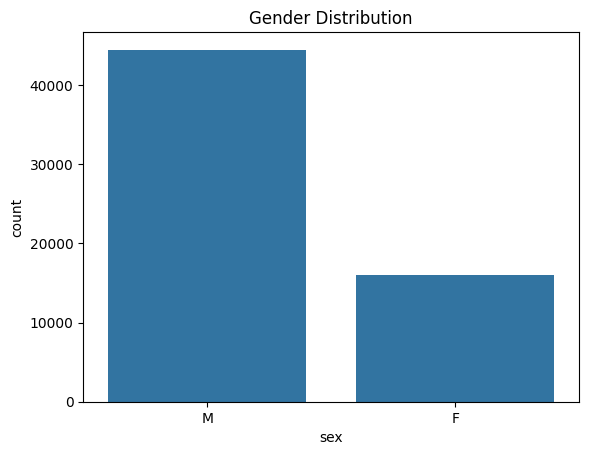

In [24]:
''' Gender Distribution '''

# Count of male and female athletes
sns.countplot(data=df, x='sex')
plt.title("Gender Distribution")
plt.show()

**observations:**
- Male athletes are significantly higher than female athletes.

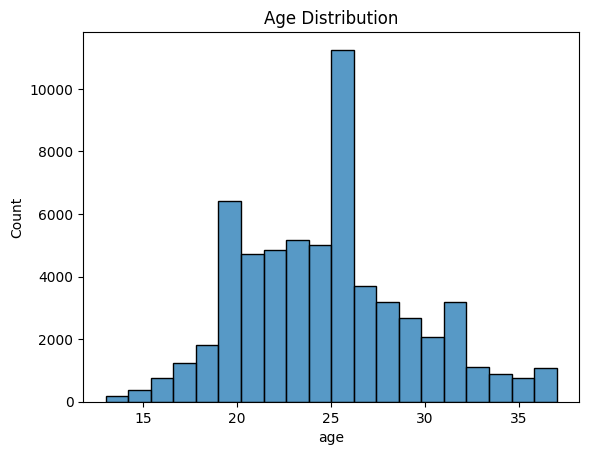

In [25]:
''' Age Distribution '''

# Distribution of athlete age
sns.histplot(data=df, x='age', bins=20)
plt.title("Age Distribution")
plt.show()

**observations:**
- Most athletes are between 20 and 30 years old.

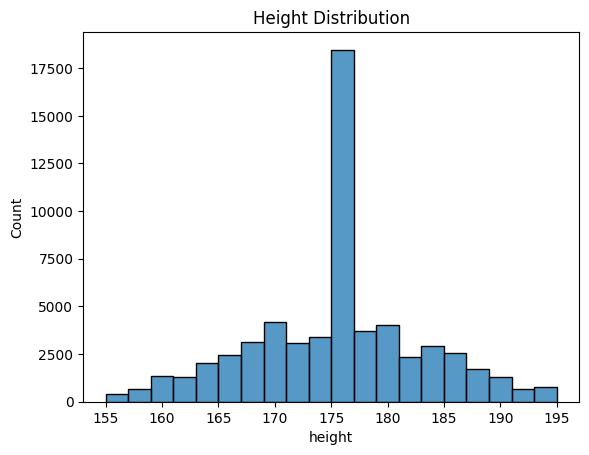

In [26]:
''' Height Distribution '''
# Distribution of athlete height
sns.histplot(data=df, x='height', bins=20)
plt.title("Height Distribution")
plt.show()

**observations:**
- Most athlete heights range between 160 cm and 190 cm.

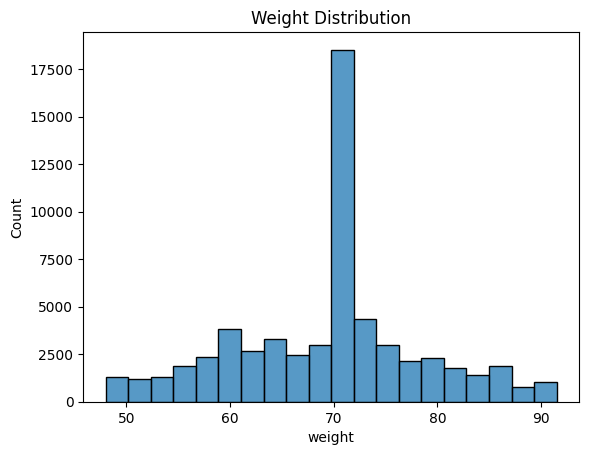

In [27]:
''' Weight Distribution '''

# Distribution of athlete weight
sns.histplot(data=df, x='weight', bins=20)
plt.title("Weight Distribution")
plt.show()

**observations:**
- Most athlete weights range between 50 kg and 80 kg.

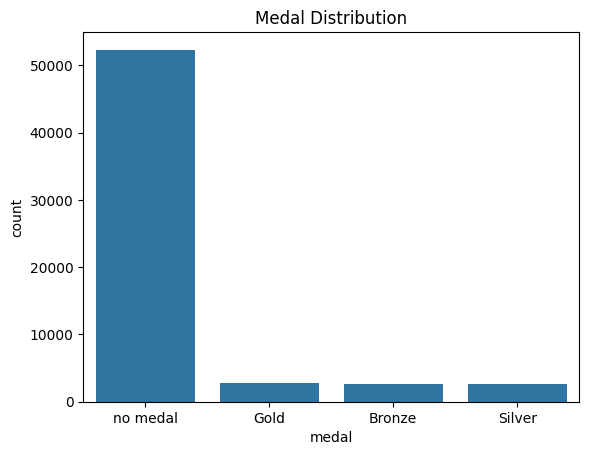

In [28]:
''' Medal Distribution '''

# Distribution of medal types
sns.countplot(data=df, x='medal')
plt.title("Medal Distribution")
plt.show()

**observations:**
- Majority of athletes did not win medals.
- Gold, Silver, and Bronze counts are relatively similar.

### 9. Bivariate Analysis

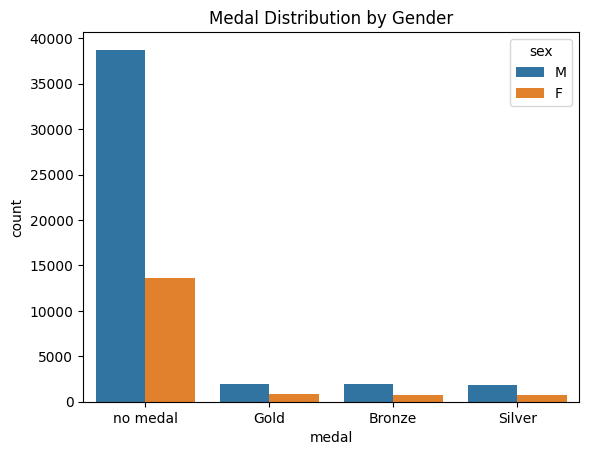

In [29]:
''' Medal vs Gender '''

# Compare medal distribution between male and female athletes
sns.countplot(data=df, x='medal', hue='sex')
plt.title("Medal Distribution by Gender")
plt.show()

**observations:**
- Male athletes have higher medal counts than female athletes.
- This reflects higher participation of male athletes.

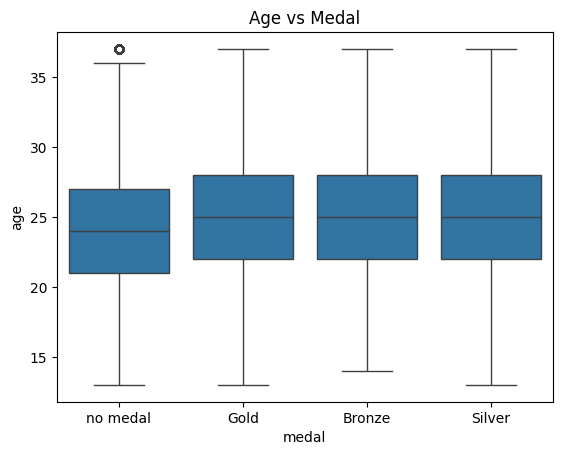

In [30]:
''' Medal vs Age '''

# Compare age distribution based on medal outcome
sns.boxplot(data=df, x='medal', y='age')
plt.title("Age vs Medal")
plt.show()

**observations:**
- Medal winners fall mostly within the 20–30 age range.
- Extreme ages are less common among medal winners.

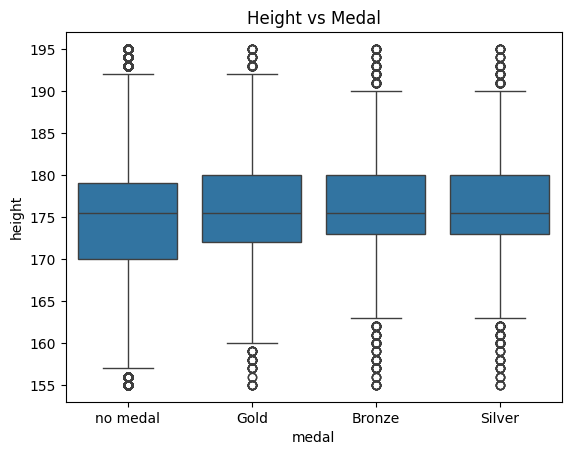

In [31]:
''' Medal vs Height '''

# Compare height distribution based on medal outcome
sns.boxplot(data=df, x='medal', y='height')
plt.title("Height vs Medal")
plt.show()

**observations:**
- Medal winners generally fall within average height ranges.
- Extremely short or tall athletes are fewer.

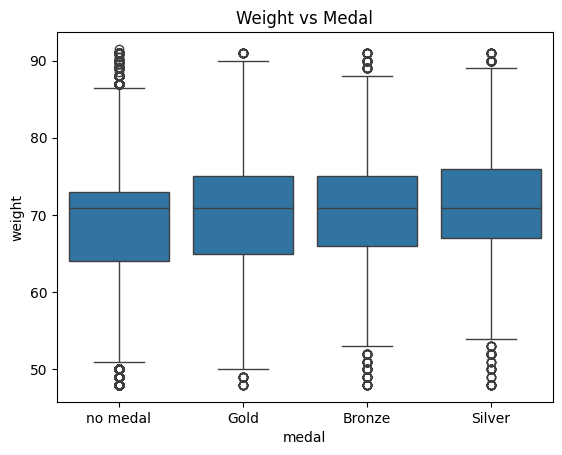

In [32]:
''' Medal vs Weight '''

# Compare weight distribution based on medal outcome
sns.boxplot(data=df, x='medal', y='weight')
plt.title("Weight vs Medal")
plt.show()

**observations**:
- Most medal winners fall within moderate weight ranges.

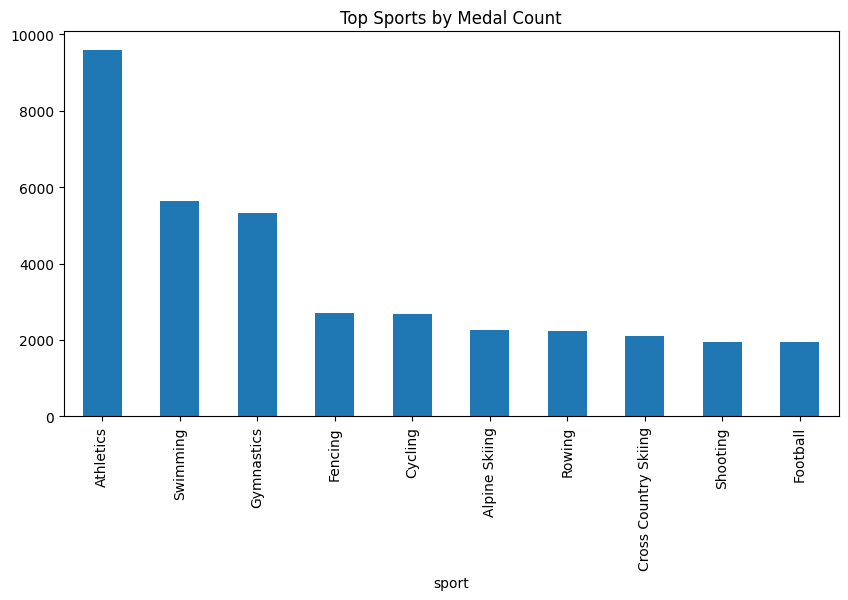

In [34]:
''' Medal count by Sport '''

# Top sports with highest medal counts
plt.figure(figsize=(10,5))
df[df['medal'] != 'No Medal']['sport'].value_counts().head(10).plot(kind='bar')
plt.title("Top Sports by Medal Count")
plt.show()

**observations:**
- Certain sports contribute more medals than others.
- Indicates uneven medal distribution across sports.

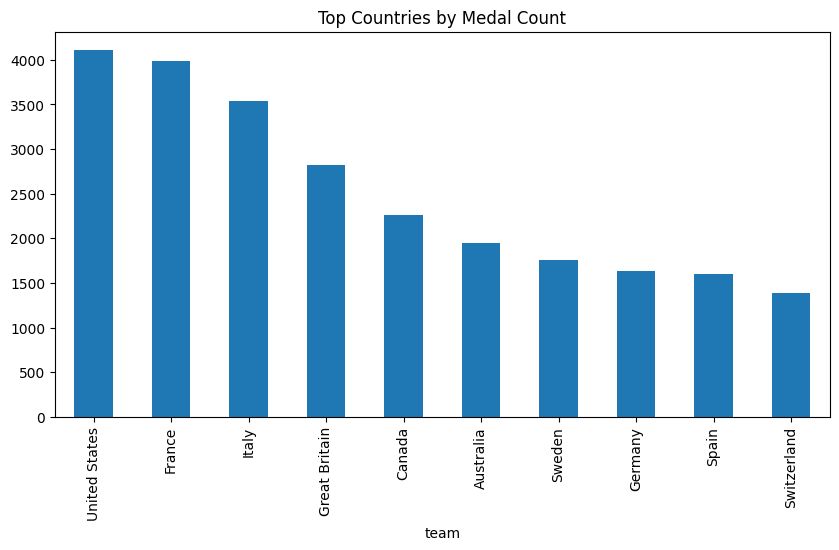

In [35]:
''' Medal count by Country '''

# Top countries with highest medal counts
plt.figure(figsize=(10,5))
df[df['medal'] != 'No Medal']['team'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries by Medal Count")
plt.show()

**observations**:
- Some countries dominate medal counts.
- Shows unequal performance across countries.

### 10. Multivariate Analysis

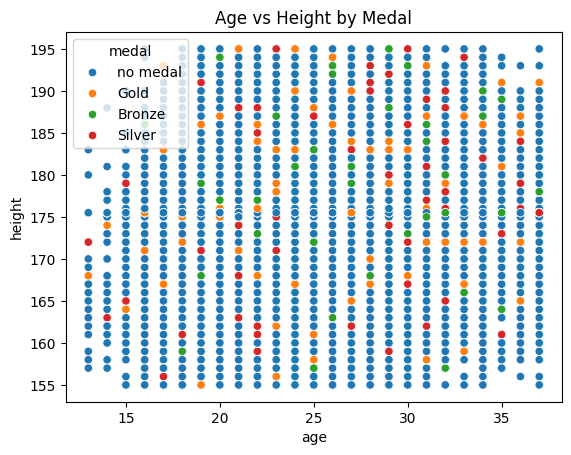

In [36]:
''' Age vs Height vs Medal '''
# Scatter plot showing Age, Height, and Medal relationship
sns.scatterplot(data=df, x='age', y='height', hue='medal')
plt.title("Age vs Height by Medal")
plt.show()

**observations:**
- Medal winners are concentrated in specific age and height ranges.
- Extreme values are less common among medal winners.

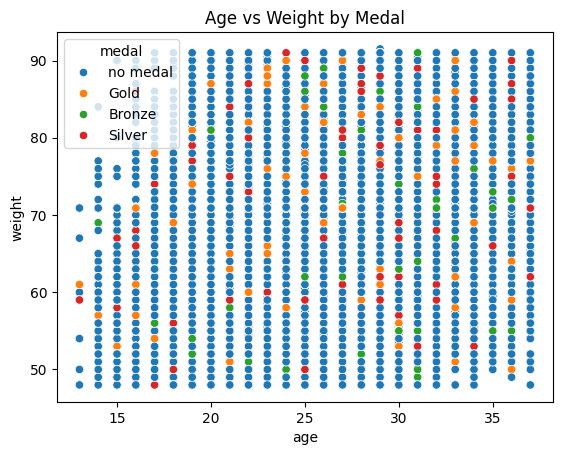

In [37]:
''' Age vs Weight vs Medal '''

# Scatter plot showing Age, Weight, and Medal relationship
sns.scatterplot(data=df, x='age', y='weight', hue='medal')
plt.title("Age vs Weight by Medal")
plt.show()

**observations:**
- Most medal winners fall within moderate age and weight ranges.
- Very low or very high weight athletes are fewer.

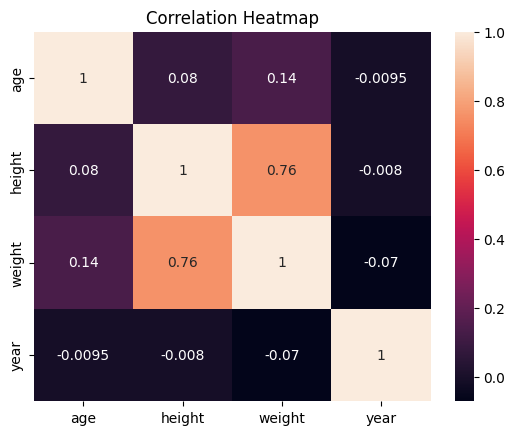

In [38]:
''' Correlation Heatmap (Numerical Relationships) '''

# Correlation between numerical variables
sns.heatmap(df[['age','height','weight','year']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**observations:**
- Height and Weight show positive correlation.
- Age has weak correlation with other variables.

In [39]:
# Pivot Table: Average Age of Medal Winners by Top 10 Countries
top_countries = df[df['medal'] != 'no medal']['team'].value_counts().head(10).index

pivot = pd.pivot_table(
    df[df['team'].isin(top_countries)],
    values='age',
    index='team',
    columns='medal',
    aggfunc='mean'
).round(1)

print("Pivot Table: Average Athlete Age by Country and Medal Type")
print(pivot)

Pivot Table: Average Athlete Age by Country and Medal Type
medal          Bronze  Gold  Silver  no medal
team                                         
Australia        24.8  24.2    24.0      24.1
Canada           23.6  25.3    25.0      24.1
France           25.7  25.6    25.9      25.0
Germany          25.8  26.4    25.1      25.6
Great Britain    25.1  26.3    25.6      24.6
Italy            26.9  26.0    26.8      24.8
Netherlands      26.1  26.4    25.9      24.4
Soviet Union     24.5  25.6    24.8      24.4
Sweden           25.6  25.7    26.6      25.3
United States    24.6  23.7    24.1      25.1


**observations:**
- Gold medal winners tend to be slightly older than No Medal athletes in most countries.
- United States gold winners are younger (~23.7 avg age) compared to other top -ations.
- Age differences across medal types are small (1-2 years), suggesting age alone
- doesn't strongly determine medal outcome.

### 11. Key Insights

- Most athletes did not win medals, showing high competition levels.
- Medal winners are mostly concentrated in the 20–30 age range.
- Height and weight show moderate influence on athlete participation and performance.
- Male athletes have higher participation and medal counts.
- Certain countries and sports dominate medal distribution.
- Outlier removal improved data consistency and reliability.

### 12. Conclusion

- Exploratory Data Analysis helped understand athlete demographics and medal patterns.
- Age, height, weight, country, and sport influence medal outcomes.
- Data cleaning, missing value handling, and outlier removal improved analysis quality.
- Visualization revealed meaningful patterns in Olympic athlete performance.
- This analysis demonstrates how EDA helps extract useful insights from large datasets.